In [2]:
# ADDS THE PARENT DIRECTORY TO SYS.PATH
import sys
import os

# Add the project root directory (one level up) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import rebound
from src.integrator.integrate import phi, phi_inv
from src.utils.plotting import plot_position_sitnikov
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt

In [3]:
e0 = 0.5

In [4]:
# We manually look for some left end of the search interval
v = 2.6
v1, t1 = phi(e = e0, v = v, t = 0)
print(v1, t1)

1.4323327026522998 9.168447562110172


In [5]:
# As a test case, we look for periodic orbits that start with some (v,0)
def single_turn_error(v):
    v1, t1 = phi(e = e0, v = v, t = 0)
    return t1 - 2*np.pi

v_per = brentq(f = single_turn_error, a = 0, b = 2.6)

c:\Users\leona\OneDrive - Universitat Politècnica de Catalunya\Desktop\ReboundTests\sitnikov\src\integrator\integrate.py:49: RuntimeWarning: phi function got value v = 0, with t = 0. Check this is intended
  warnings.warn(f"phi function got value v = 0, with t = {t}. Check this is intended", RuntimeWarning)


# Random sprinkling to generate stable/unstable manifolds

C:\Users\leona\AppData\Local\Temp\ipykernel_3132\3482201843.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


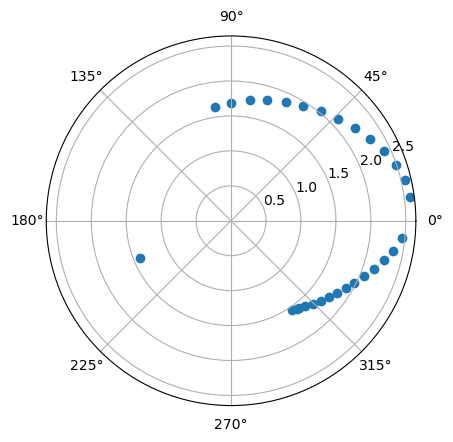

In [ ]:
v_vals = []
t_vals = []

# We try to compute points of the unstable manifold of (v_per, 0)
N_rep = 100
for _ in range(N_rep):
    v_start = v_per + 1e-13*(2*np.random.random() - 1)
    t_start = 1e-13*(2*np.random.random() - 1) 
    v1 = v_start
    t1 = t_start
    while np.sqrt( (v1 - v_start)**2 + (t1 - t_start)**2) < 0.1:
        v1, t1 = phi(e0, v1, t1)
        t1 = t1 - 2*np.pi # specific for this point
    
    v_vals.append(v1)
    t_vals.append(t1)

v_vals = np.array(v_vals)
t_vals = np.array(t_vals)

fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.scatter(t_vals, v_vals)
ax.scatter(np.array([v_per]), np.array([0]))
fig.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_3132\2281611317.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


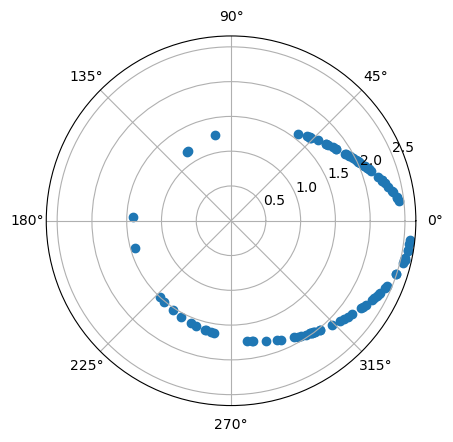

In [54]:
v_vals2 = []
t_vals2 = []

# We try to compute points of the stable manifold of (v_per, 0)
N_rep = 100
for _ in range(N_rep):
    v_start = v_per + 1e-13*(2*np.random.random() - 1)
    t_start = 1e-13*(2*np.random.random() - 1) 
    v1 = v_start
    t1 = t_start
    while np.sqrt( (v1 - v_start)**2 + (t1 - t_start)**2) < 0.1:
        v1, t1 = phi_inv(e0, v1, t1)
        t1 = t1 + 2*np.pi # specific for this point
    
    v_vals2.append(v1)
    t_vals2.append(t1)

v_vals2 = np.array(v_vals2)
t_vals2 = np.array(t_vals2)

fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.scatter(t_vals2, v_vals2)
fig.show()

In [8]:
bound_D0_tv = np.load("../boundary_test1/e0_5__v2_eps0_001__deltmax_100.npy")
bound_D1_tv = np.block([[-bound_D0_tv[0]], [bound_D0_tv[1]]])

C:\Users\leona\AppData\Local\Temp\ipykernel_3132\521025655.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


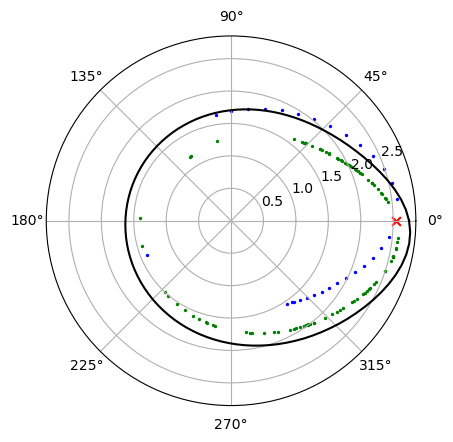

In [64]:
fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.plot(bound_tv[0], bound_tv[1], c = 'black')
ax.scatter(t_vals, v_vals, s = 2, c = 'blue')
ax.scatter(t_vals2, v_vals2, s = 2, c = 'green')
ax.scatter(np.array([0]), np.array([v_per]), s = 40, c = 'red', marker = 'x')
fig.show()

# Linear sprinkling to generate unstable/stable manifolds (quicker)

We first focus on the stable manifold, which is the set of points that in the future forward will go to the fixed point. Therefore it is part of NE, and thus of D0.

In [68]:
def iterations_before_escape(f, e, v, t):
    count = 0
    v1, t1 = f(e, v, t)
    while v1 is not None:
        count = count + 1
        v1, t1 = f(e, v1, t1)
    
    return count

In [69]:
n = iterations_before_escape(f = phi, e = e0, v = v_per, t = 0)

In [73]:
dv = 1e-13
n_left_phi = iterations_before_escape(f = phi, e = e0, v = v_per - dv, t = 0)
n_right_phi = iterations_before_escape(f = phi, e = e0, v = v_per + dv, t = 0)
n_left_phi_inv = iterations_before_escape(f = phi_inv, e = e0, v = v_per - dv, t = 0)
n_right_phi_inv = iterations_before_escape(f = phi_inv, e = e0, v = v_per + dv, t = 0)

In [76]:
print("Forward escape around p happens after around {0}, {1}, {2}".format(n_left_phi, n, n_right_phi))
print("Backward escape around p happens after around {0}, {1}".format(n_left_phi_inv, n_right_phi_inv))


Forward escape around p happens after around 10, 9, 15
Backward escape around p happens after around 10, 15


In [ ]:
W_stable_vt = [[],[]]

# We compute points of the stable manifold of (v_per, 0)
N_iterates = 9
N_rep = 120
dv = 1e-13
step = 2*dv/(N_rep-1)
for i in range(N_rep//2):
    v_start = v_per - dv + step*i 
    t_start = 0
    v1 = v_start
    t1 = t_start
    for j in range(N_iterates):
        v1, t1 = phi_inv(e0, v1, t1, t_max = 20)
        if v1 is None or t1 is None:
            print("Note escape has happened", i, j)
            break
        t1 = t1 % (2* np.pi)
        delta_v = v1 - v_start
        delta_t = t1 - t_start
        delta_t = ( delta_t + np.pi ) % (2*np.pi) - np.pi # We measure distance mod 2pi
        if np.sqrt( (delta_v)**2 + (delta_t)**2 ) > 0.01:
            W_stable_vt[0].append(v1)
            W_stable_vt[1].append(t1)


W_stable_vt = np.array(W_stable_vt)

In [37]:
W_unstable_vt = [[],[]]

# We compute points of the stable manifold of (v_per, 0)
N_iterates = 8
N_rep = 30
dv = 1e-13
step = 2*dv/(N_rep-1)
for i in range(N_rep):
    v_start = v_per - dv + step*i 
    t_start = 0
    v1 = v_start
    t1 = t_start
    for j in range(N_iterates):
        v1, t1 = phi(e0, v1, t1, t_max = 20)
        if v1 is None or t1 is None:
            print("Note escape has happened", i, j)
            break
        t1 = t1 % (2* np.pi)
        delta_v = v1 - v_start
        delta_t = t1 - t_start
        delta_t = ( delta_t + np.pi ) % (2*np.pi) - np.pi # We measure distance mod 2pi
        if np.sqrt( (delta_v)**2 + (delta_t)**2 ) > 0.01:
            W_unstable_vt[0].append(v1)
            W_unstable_vt[1].append(t1)


W_unstable_vt = np.array(W_unstable_vt)

C:\Users\leona\AppData\Local\Temp\ipykernel_11988\1845152974.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


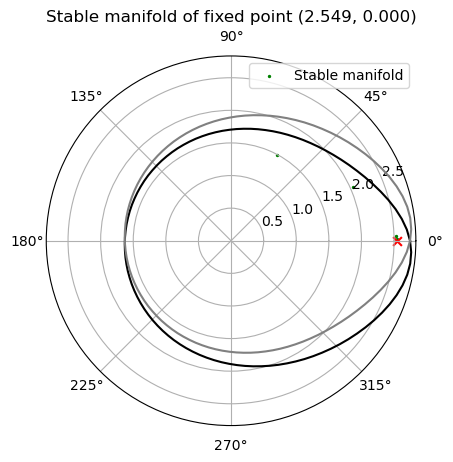

In [ ]:
fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.set_title("Stable manifold of fixed point ({0:.3f}, {1:.3f})".format(v_per, 0))
ax.plot(bound_D0_tv[0], bound_D0_tv[1], c = 'black')
ax.plot(bound_D1_tv[0], bound_D1_tv[1], c = 'grey')

ax.scatter(W_stable_vt[1], W_stable_vt[0], s = 2, c = 'green', label = "Stable manifold")
# ax.scatter(W_unstable_vt[1], W_unstable_vt[0], s = 2, c = 'blue', label = "Stable manifold")
ax.scatter(np.array([0]), np.array([v_per]), s = 40, c = 'red', marker = 'x')

ax.legend()
fig.show()

In [12]:
print(W_stable_vt.shape)

(2, 160)


# Adaptive step stable manifold branch computation

In [51]:
N_it = 7
dv = -2e-14
v1 = v_per + dv
t1 = 0
for _ in range(N_it):
    v1, t1 = phi_inv(e=e0, v = v1, t = t1)

norm = np.sqrt(v1**2 + t1**2)
stab_neg_dir_vt = np.array([v1/norm, t1/norm]) 

In [58]:
W_stable_vt_adaptive = [[],[]]
N_iterates = 8
max_time = 20
target_spacing = 0.1
max_spacing = 2*target_spacing
min_spacing = target_spacing/2

dv = -1e-14
step = -1e-14 # We go towards the negative branch of W_s
escaped = False

while not escaped:
    v_start = v_per + dv*stab_neg_dir_vt[0]
    t_start = dv*stab_neg_dir_vt[1]
    v1 = v_start
    t1 = t_start
    for i in range(N_iterates):
        v1, t1 = phi_inv(e = e0, v = v1, t = t1, t_max= max_time)
        t1 = t1 % (2*np.pi)
        if v1 is None or t1 is None:
            print("Escape encountered for dv = {0}, with {1} iterations".format(dv, i))
            escaped = True
            break
    
    if escaped:
        break

    if W_stable_vt_adaptive[0] == []:
        W_stable_vt_adaptive[0].append(v1)
        W_stable_vt_adaptive[1].append(t1)
        print("Value dv = {0:.2e} completed with final t1 = {1:.2f}".format(dv, t1))
        dv = dv + step


    else:
        v1_prev = W_stable_vt_adaptive[0][-1]
        t1_prev = W_stable_vt_adaptive[1][-1]
        delta_t = t1 - t1_prev
        delta_t = delta_t % (2*np.pi)
        delta_t = min(np.abs(delta_t), np.abs(2*np.pi - delta_t)) 
        delta_v = v1 - v1_prev
        spacing = np.sqrt(delta_t**2 + delta_v**2)
        if spacing > max_spacing:
            dv = dv - step + step/1.5
            step = step/1.5
        elif spacing < min_spacing:
            dv = dv - step + step*1.5
            step = step*1.5
        else:
            W_stable_vt_adaptive[0].append(v1)
            W_stable_vt_adaptive[1].append(t1)
            print("Value dv = {0:.2e} completed with final t1 = {1:.2f}".format(dv, t1))
            dv = dv + step

            
W_stable_vt_adaptive = np.array(W_stable_vt_adaptive)

Value dv = -1.00e-14 completed with final t1 = 5.76
Value dv = -2.00e-14 completed with final t1 = 5.87
Value dv = -3.00e-14 completed with final t1 = 5.98
Value dv = -4.00e-14 completed with final t1 = 6.08
Value dv = -5.00e-14 completed with final t1 = 6.18
Value dv = -6.00e-14 completed with final t1 = 6.26
Value dv = -7.00e-14 completed with final t1 = 0.05
Value dv = -8.00e-14 completed with final t1 = 0.13
Value dv = -9.00e-14 completed with final t1 = 0.21
Value dv = -1.00e-13 completed with final t1 = 0.28
Value dv = -1.10e-13 completed with final t1 = 0.36
Value dv = -1.20e-13 completed with final t1 = 0.43
Value dv = -1.30e-13 completed with final t1 = 0.50
Value dv = -1.40e-13 completed with final t1 = 0.57
Value dv = -1.50e-13 completed with final t1 = 0.64
Value dv = -1.60e-13 completed with final t1 = 0.71
Value dv = -1.70e-13 completed with final t1 = 0.77
Value dv = -1.80e-13 completed with final t1 = 0.83
Value dv = -1.90e-13 completed with final t1 = 0.90
Value dv = -

KeyboardInterrupt: 

In [46]:
print(step)

-1.2974633789062497e-12


C:\Users\leona\AppData\Local\Temp\ipykernel_11988\3660865731.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


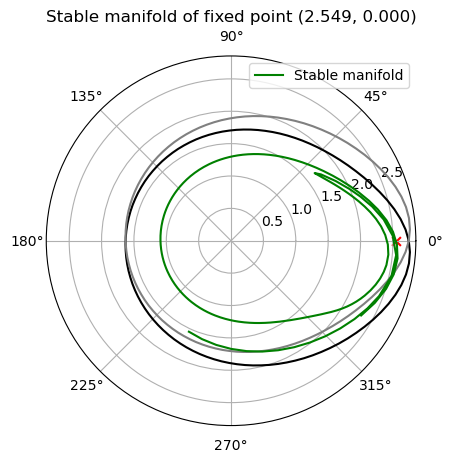

In [59]:
W_stable_vt_adaptive = np.array(W_stable_vt_adaptive)
fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.set_title("Stable manifold of fixed point ({0:.3f}, {1:.3f})".format(v_per, 0))
ax.plot(bound_D0_tv[0], bound_D0_tv[1], c = 'black')
ax.plot(bound_D1_tv[0], bound_D1_tv[1], c = 'grey')

ax.plot(W_stable_vt_adaptive[1], W_stable_vt_adaptive[0], c = 'green', label = "Stable manifold")
ax.scatter(np.array([0]), np.array([v_per]), s = 40, c = 'red', marker = 'x')

ax.legend()
fig.show()